# Testing the draft histogram (`new_graphics/hist.py`)

This notebook exercises `make_hist()`, the draft implementation of the new histogram
plot type from the approved Task 1E prototype. It is **not** wired into `.plot()` yet —
this is for visually checking the draft before integration.

**How to run:** open this notebook from the `new_graphics/` folder (so `from hist import ...`
works) using the `symbulate` conda environment, then Run All.

**What to look for in every plot:**
- Bars have thin white edges so adjacent bars stay distinct
- Light horizontal reference grid, drawn *behind* the bars
- Top and right spines removed
- y-axis reads "Density" (or "Count" when `normalize=False`)

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# The draft helper and its per-plot-type constants
from hist import make_hist, HIST_ALPHA, HIST_DEFAULT_BINS

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = Path.cwd().parent / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"HIST_ALPHA = {HIST_ALPHA}, HIST_DEFAULT_BINS = {HIST_DEFAULT_BINS}")

HIST_ALPHA = 0.65, HIST_DEFAULT_BINS = 30


## 1. Reproduce the approved prototype

This should match the prototype image: sky-blue density histogram of
roughly Normal(10, 2) data, centered near 10, x-axis from about 3 to 16.

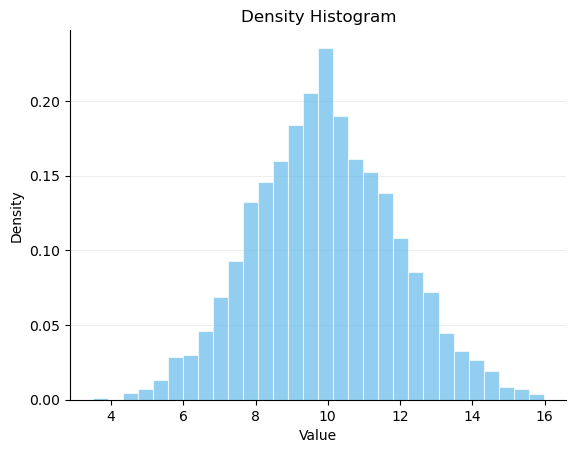

In [9]:
values = rng.normal(10, 2, 2000)

ax = plt.gca()
make_hist(values, ax, "#56B4E9")  # Okabe-Ito sky blue, as in the prototype
plt.show()

## 2. Options: counts, custom bins, custom alpha

`normalize=False` should switch the y-axis label to "Count".

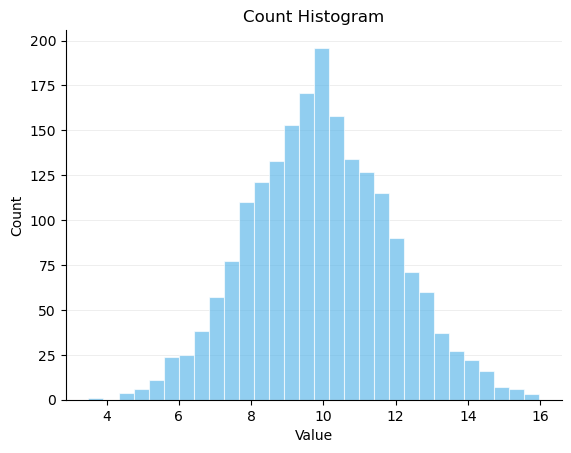

In [10]:
ax = plt.gca()
make_hist(values, ax, "#56B4E9", normalize=False)
plt.show()

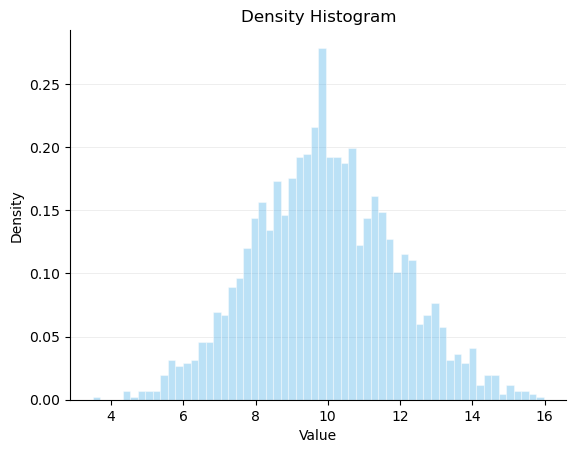

In [11]:
# More bins, more transparent
ax = plt.gca()
make_hist(values, ax, "#56B4E9", bins=60, alpha=0.4)
plt.show()

## 3. Overlay behavior — mimicking two `.plot()` calls

In the final integration, each `.plot()` call takes its color from
`get_next_color(ax)`. Two overlaid histograms should come out in distinct
Okabe-Ito hues, and at alpha 0.65 the overlap region should stay readable.

Note the cycle order: the first color is **orange** (`#E69F00`), the second is the
prototype's sky blue — flagged for the team in `hist.py`.

(Importing `symbulate` currently switches the matplotlib style back to the old
seaborn/ggplot stylesheet — a Phase 2 item — so we re-apply ours right after.)

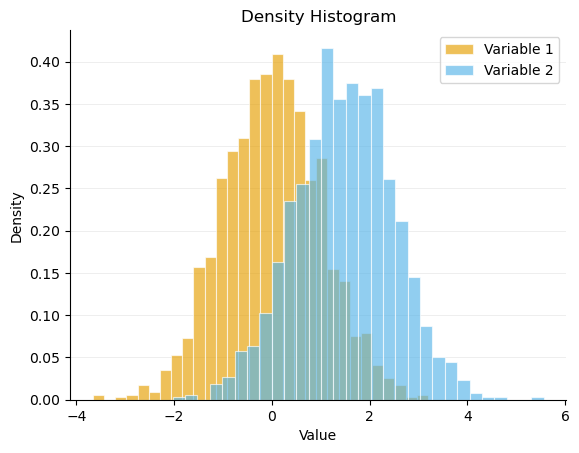

In [12]:
from symbulate.plot import get_next_color

plt.style.use(STYLE_PATH)  # re-apply: importing symbulate overrides the style

sample_a = rng.normal(0, 1, 1500)
sample_b = rng.normal(1.5, 1, 1500)

ax = plt.gca()
make_hist(sample_a, ax, get_next_color(ax))
make_hist(sample_b, ax, get_next_color(ax))
plt.show()

## 4. With real symbulate simulation data

Same prototype, but the data comes from an actual `RV(...).sim(...)` call instead
of raw numpy.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

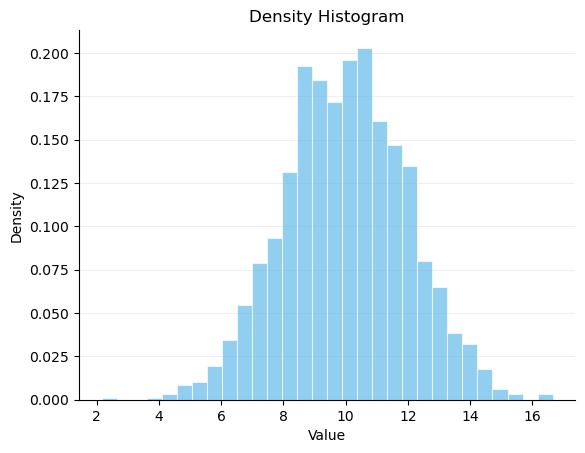

In [13]:
from symbulate import RV, Normal

sims = RV(Normal(10, 2)).sim(2000)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_hist(np.asarray(sims.results), ax, "#56B4E9")
plt.show()

## 5. The classic teaching use case: true pdf over the simulated histogram

`Normal(10, 2).plot()` draws on the same axes via `plt.gca()`, so the curve
should overlay the histogram and pick up the next color in the cycle. The
histogram's 0.65 alpha should leave the curve clearly visible.

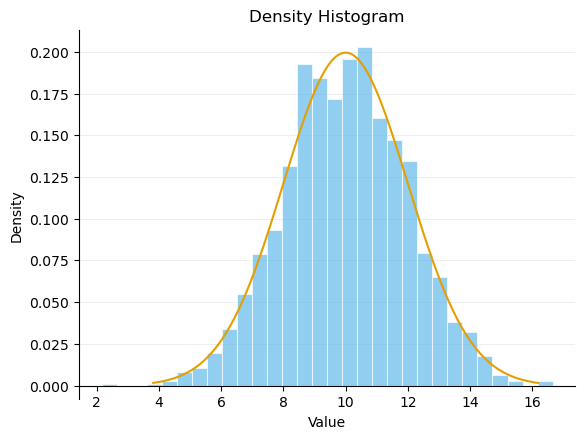

In [14]:
ax = plt.gca()
make_hist(np.asarray(sims.results), ax, "#56B4E9")
Normal(10, 2).plot()  # true pdf, drawn on the same axes
plt.show()

## Verification checklist

- [ ] Section 1 matches the approved prototype image
- [ ] White bar edges visible; bars distinct
- [ ] Horizontal grid behind the bars; no top/right spines
- [ ] `normalize=False` shows "Count" on the y-axis
- [ ] `bins=` and `alpha=` overrides work
- [ ] Overlaid histograms get distinct Okabe-Ito colors and stay readable
- [ ] Works on real `.sim()` output, not just numpy arrays
- [ ] True pdf curve overlays cleanly on the histogram